Постановка задачи:

Есть обыкновенное дифференциальное уравнение первого порядка, разрешенное относительно производной $\frac{dy}{dt} = \lambda y$, где $\lambda = -1$.

Решением этого уравнения будет считаться функция (функции) $y = y(t)$, обращающая приведенное выше выражение в тождество на отрезке $[a,b]$ 

Решим его $методом \ Эйлера$ $(метод \ степенных \ рядов)$



In [141]:
"""
Для постановки задачи Коши нам необходимо какое-то начальное значение, сделаем его выбор произвольным, но
для определенности зафиксируем конкретное.
"""

y0 = 15
Lambda = -1


In [142]:
"""
Зададим произвольный отрезок [a, b], однако, все же, зафиксируем границы (для определенности)
"""

a = -50
b = 10

In [143]:
"""
Создадим функцию разбиения промежутка [a,b] на N интервалов
"""

def grid(a, b, N):
    h = (b - a)/N
    grid = [a + i*h for i in range(N + 1)]
    return grid, h


In [144]:
"""
Напишем функцию нахождения значения y_{j+1} приближенного решения в точке t_{j+1} = t_{j} + h
"""

def power_series_method_1(t, y, h, f):
    return y + h*f(t, y)

In [145]:
"""
Для двух следующих функций потребуется так же написать функции производной
"""

def f(t, y):
    return Lambda * y

def f_t(t, y):
    return 0.0

def f_y(t, y):
    return Lambda

def f_tt(t, y):
    return 0.0

def f_ty(t, y):
    return 0.0

def f_yy(t, y):
    return 0.0



In [146]:
"""
Напишем теперь функции нахождения значения y_{j+1} с большими порядками точности
"""


def power_series_method_2(t, y, h, f):
    F = f(t, y)
    y2 = f_t(t, y) + F * f_y(t, y)         
    return y + h * F + (h**2) / 2.0 * y2


def power_series_method_3(t, y, h, f):
    F = f(t, y)
    ft = f_t(t, y)
    fy = f_y(t, y)

    y2 = ft + F * fy


    y3 = (
        f_tt(t, y)
        + 2.0 * F * f_ty(t, y)
        + ft * fy
        + F * (fy**2)
        + (F**2) * f_yy(t, y)
    )

    return y + h * F + (h**2) / 2.0 * y2 + (h**3) / 6.0 * y3


In [147]:
"""
Импортируем библиотеку для отрисовки графиков, а также Numpy
"""

import matplotlib.pyplot as plt
import numpy as np

In [148]:
"""
Зададим теперь сетку и пустой массив для отрисовки значений
"""
N = 10000

values_1 = [y0]
values_2 = [y0]
values_3 = [y0]

domain, h = grid(a, b, N)

f = lambda t, y: Lambda * y

for t in range(1, len(domain)):
    values_1.append(power_series_method_1(domain[t-1], values_1[t-1], h, f))
    values_2.append(power_series_method_2(domain[t-1], values_2[t-1], h, f))
    values_3.append(power_series_method_3(domain[t-1], values_3[t-1], h, f))

print(domain)

print(values_1)
print(values_2)
print(values_3)



[-50.0, -49.994, -49.988, -49.982, -49.976, -49.97, -49.964, -49.958, -49.952, -49.946, -49.94, -49.934, -49.928, -49.922, -49.916, -49.91, -49.904, -49.898, -49.892, -49.886, -49.88, -49.874, -49.868, -49.862, -49.856, -49.85, -49.844, -49.838, -49.832, -49.826, -49.82, -49.814, -49.808, -49.802, -49.796, -49.79, -49.784, -49.778, -49.772, -49.766, -49.76, -49.754, -49.748, -49.742, -49.736, -49.73, -49.724, -49.718, -49.712, -49.706, -49.7, -49.694, -49.688, -49.682, -49.676, -49.67, -49.664, -49.658, -49.652, -49.646, -49.64, -49.634, -49.628, -49.622, -49.616, -49.61, -49.604, -49.598, -49.592, -49.586, -49.58, -49.574, -49.568, -49.562, -49.556, -49.55, -49.544, -49.538, -49.532, -49.526, -49.52, -49.514, -49.508, -49.502, -49.496, -49.49, -49.484, -49.478, -49.472, -49.466, -49.46, -49.454, -49.448, -49.442, -49.436, -49.43, -49.424, -49.418, -49.412, -49.406, -49.4, -49.394, -49.388, -49.382, -49.376, -49.37, -49.364, -49.358, -49.352, -49.346, -49.34, -49.334, -49.328, -49.322,

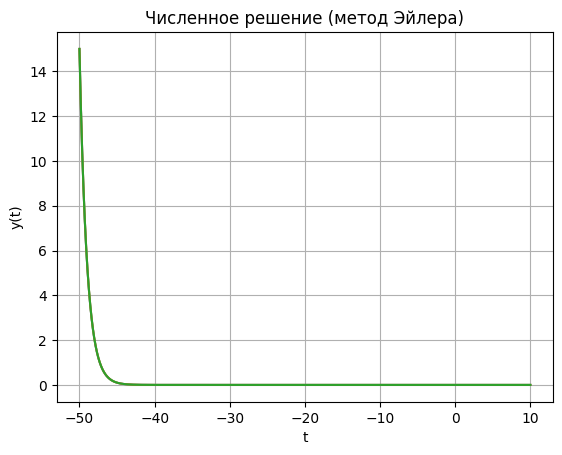

In [156]:
plt.figure()
plt.plot(domain, values_1)
plt.plot(domain, values_2)
plt.plot(domain, values_3)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Численное решение (метод Эйлера)")
plt.grid(True)
plt.show()

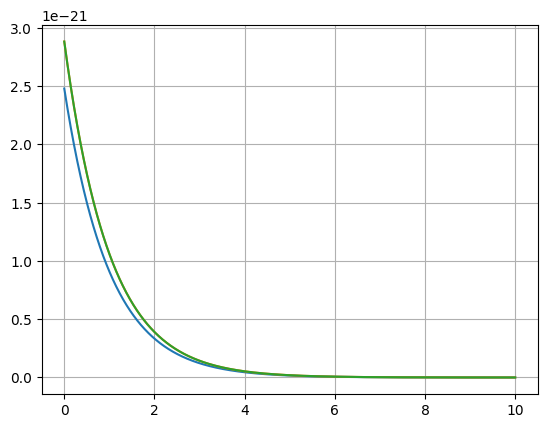

In [155]:
mask = [0 <= t <= 10 for t in domain]

domain_zoom = [t for t, m in zip(domain, mask) if m]
v1_zoom = [v for v, m in zip(values_1, mask) if m]
v2_zoom = [v for v, m in zip(values_2, mask) if m]
v3_zoom = [v for v, m in zip(values_3, mask) if m]

plt.figure()
plt.plot(domain_zoom, v1_zoom)
plt.plot(domain_zoom, v2_zoom)
plt.plot(domain_zoom, v3_zoom)
plt.grid(True)
plt.show()
